In [ ]:
from torchmetrics.classification import MultilabelAveragePrecision
from torch.utils.data import DataLoader
from datasets import load_dataset
from model import Tagger
from torch import Tensor
from utils import transform_test
import torch, dotenv, os

In [ ]:
dotenv.load_dotenv()
token = os.getenv('HF_TOKEN')

device = 'cuda'

In [ ]:
model = Tagger().to(device)

model.load_state_dict(torch.load('outputs/Best2-E5.pt')['model_state_dict'])

In [ ]:
to_predict = (
    'female', 'male',
    'unicorn', 'pegasus', 'earth pony', 'alicorn',
    'simple background', 'monochrome',
    'clothes', 'wings', 'horn', 'chest fluff', 'ear fluff', 'hat', 'jewelry', 'food', 'foal',
    'looking at you', 'smiling', 'open mouth', 'blushing', 'sitting', 'raised hoof', 'eyes closed',
    'twilight sparkle', 'fluttershy', 'rainbow dash', 'pinkie pie', 'rarity', 'applejack'
)

In [ ]:
ds = load_dataset('Brambles/Ponies', token=token)

In [ ]:
batch_size = 64

In [ ]:
def transform(batch):
    return {
        'images': torch.stack([transform_test(img) for img in batch['image']]),
        'tags': torch.tensor(batch['tags'], dtype=torch.float32)
    }

In [ ]:
dl_test = DataLoader(
    ds['test'].with_transform(transform),
    batch_size=batch_size,
    pin_memory=True,
    num_workers=2,
    persistent_workers=True,
)

In [ ]:
def test(model):
    model.eval()
    logits = torch.zeros((len(ds['test']), len(to_predict)))

    with torch.no_grad():
        for i, batch in enumerate(dl_test):
            X: Tensor = batch['images'].to(device)

            logits[i * batch_size : (i + 1) * batch_size] = model(X)
            print(f'\r{(i+1)*100/len(dl_test):.1f}%', end='')

        print()
        return logits.sigmoid()

In [ ]:
f = MultilabelAveragePrecision(len(to_predict))

preds = test(model)
labels = torch.as_tensor(ds['test']['tags'])

print(f'mAP: {f(preds, labels):.3f}')

In [31]:
from utils import show_imgs, show_preds, confusion_matrix
from torchvision.transforms.functional import pil_to_tensor
import numpy as np, pandas as pd
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

/tmp/ipykernel_10159/809348055.py:15: RuntimeWarning: invalid value encountered in divide
  f1 = 2 * precision * recall / (precision + recall)
/tmp/ipykernel_10159/809348055.py:15: RuntimeWarning: invalid value encountered in divide
  f1 = 2 * precision * recall / (precision + recall)
/tmp/ipykernel_10159/809348055.py:15: RuntimeWarning: invalid value encountered in divide
  f1 = 2 * precision * recall / (precision + recall)
/tmp/ipykernel_10159/809348055.py:15: RuntimeWarning: invalid value encountered in divide
  f1 = 2 * precision * recall / (precision + recall)
/tmp/ipykernel_10159/809348055.py:15: RuntimeWarning: invalid value encountered in divide
  f1 = 2 * precision * recall / (precision + recall)
/tmp/ipykernel_10159/809348055.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Macro f1: 0.728


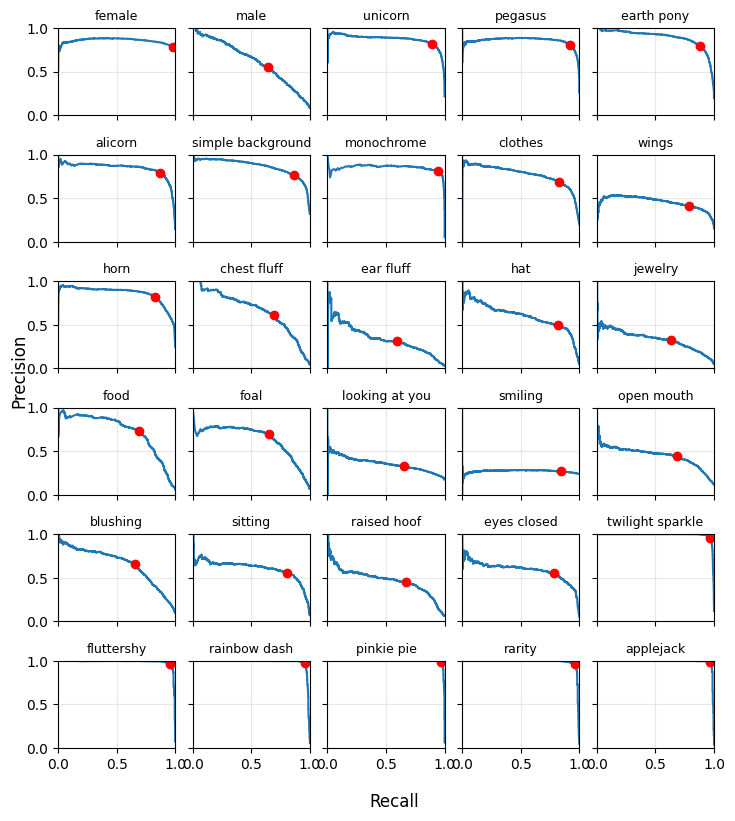

In [ ]:
fig, ax = plt.subplots(6, 5, figsize=(8, 9))
ax: list[Axes] = ax.flatten()
f1s = np.zeros(len(to_predict))
thresholds = np.zeros_like(f1s)

for i, axis in enumerate(ax):
    y_true = labels[:, i].cpu().numpy()
    y_score = preds[:, i].cpu().numpy()

    precision, recall, threshold = precision_recall_curve(y_true, y_score)
    f1 = 2 * precision * recall / (precision + recall)
    idx_best_f1 = np.nanargmax(f1)
    f1s[i] = np.nanmax(f1)
    thresholds[i] = threshold[idx_best_f1]

    axis.plot(recall, precision)
    axis.plot(recall[idx_best_f1], precision[idx_best_f1], 'ro')
    axis.set_title(to_predict[i], fontsize=9)
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.grid(alpha=.3)

for axis in ax:
    axis.label_outer()

fig.supxlabel('Recall')
fig.supylabel('Precision')

fig.subplots_adjust(
    left=0.08,
    bottom=0.08,
    wspace=0.15,
    hspace=0.45
)

print(f'Macro f1: {f1s.mean():.3f}')
fig.show()

In [32]:
pd.set_option('display.precision', 3)

confusion_matrix(preds > torch.from_numpy(thresholds), labels, to_predict)

,tag,f1,precision,recall,tp,fp,tn,fn,count
27,pinkie pie,0.979,0.989,0.970,740,8,11158,23,763
29,applejack,0.973,0.983,0.962,461,8,11442,18,479
26,rainbow dash,0.966,0.978,0.955,652,15,11231,31,683
24,twilight sparkle,0.964,0.959,0.969,1388,59,10438,44,1432
28,rarity,0.959,0.959,0.959,580,25,11299,25,605
25,fluttershy,0.957,0.957,0.956,825,37,11029,38,863
7,monochrome,0.875,0.815,0.945,583,132,11180,34,617
0,female,0.874,0.786,0.984,8712,2367,706,144,8856
3,pegasus,0.862,0.808,0.925,2844,675,8178,232,3076
2,unicorn,0.856,0.820,0.895,2300,505,8853,271,2571


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1022654].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.640001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6400015].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.640001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6400006].


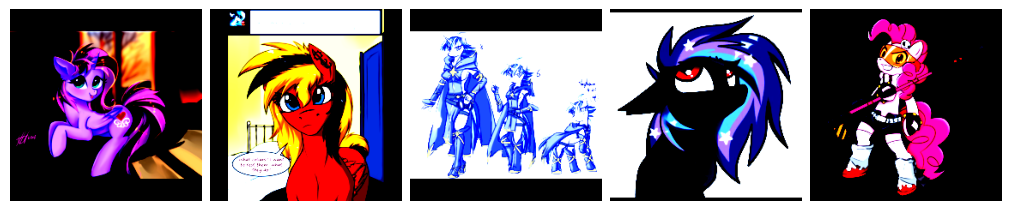

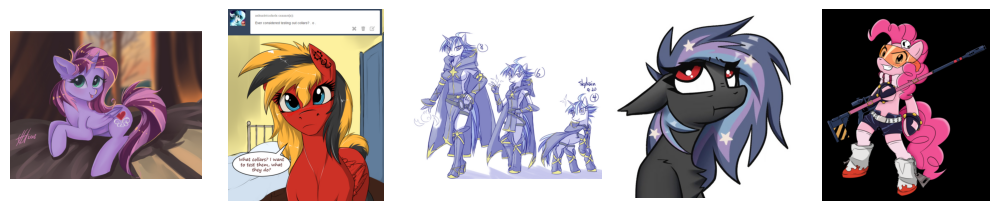

          smiling:  1.00  1
   looking at you:  1.00  1
           female:  0.99  0
       open mouth:  0.98  0
        ear fluff:  0.98  0
            wings:  0.94  1
          alicorn:  0.85  1
      chest fluff:  0.83  0
             horn:  0.67  1
         blushing:  0.57  0

          pegasus:  1.00  1
          smiling:  0.99  0
   looking at you:  0.99  1
           female:  0.96  0
          jewelry:  0.95  1
            wings:  0.91  0

             horn:  1.00  1
          unicorn:  1.00  1
          clothes:  0.99  1
simple background:  0.97  0
             male:  0.73  0
           female:  0.68  1
          smiling:  0.64  0

      chest fluff:  1.00  1
simple background:  1.00  1
          smiling:  0.98  0
           female:  0.97  0
   looking at you:  0.94  0
        ear fluff:  0.86  0
             horn:  0.56  0

       pinkie pie:  1.00  1
       earth pony:  1.00  1
          clothes:  1.00  1
           female:  1.00  1
simple background:  0.99  1
          smilin

In [38]:
idx_obs = np.random.choice(len(ds['test']), 5, False)
X, y = zip(*[(ds['test'][i]['image'], ds['test'][i]['tags']) for i in idx_obs])

batch = {
    'images': torch.stack([transform_test(x) for x in X]),
    'tags': torch.tensor(y)
}

X_t, y = batch['images'].to(device), batch['tags'].to(device)

with torch.no_grad():
    model.eval()

    logits = model(X_t).to(device)
    logits = logits.sigmoid()

    show_imgs(X_t.cpu())
    X = [image.convert('RGB') for image in X]
    show_imgs([pil_to_tensor(x) for x in X])

    show_preds(y.cpu(), logits.cpu().numpy(), to_predict)